In [1]:
# Our goal is to analyse Netflix dataset to understand content distribution, trends, and build a predictive model
# to classify content type or popularity.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('netflix_titles.csv')

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.describe(include = 'object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [9]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [10]:
# DATA UNDERSTANDING
#• understand the data structure
#• check the data types
#• identify null values
#• check for unique values
#• check for duplicate records
#• get an overview of the dataset

In [11]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [12]:
df.isnull().sum().sort_values(ascending = False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [13]:
(df.isnull().sum()/len(df)*100).round(2).sort_values(ascending = False)

director        29.91
country          9.44
cast             9.37
date_added       0.11
rating           0.05
duration         0.03
show_id          0.00
type             0.00
title            0.00
release_year     0.00
listed_in        0.00
description      0.00
dtype: float64

In [14]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

In [15]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [16]:
df.duplicated().sum()

0

In [17]:
df.describe().round(2)

,release_year
count,8807.00
mean,2014.18
std,8.82
min,1925.00
25%,2013.00
50%,2017.00
75%,2019.00
max,2021.00


In [18]:
df.describe(include = 'object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [19]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [20]:
num_cols = df.select_dtypes(include = ['int','float']).columns

In [21]:
num_cols

Index(['release_year'], dtype='object')

In [22]:
categorical_cols = df.select_dtypes(include = 'object').columns

In [23]:
categorical_cols

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [24]:
# Data understanding is the process of analyzing dataset structure, datatypes, 
# missing values, and feature information before cleaning and modeling

In [25]:
# DATA CLEANING
#• handle missing values
#• remove duplicate records
#• correct data types
#• fix inconsistent values
#• create a model-ready dataset

In [26]:
df.drop_duplicates(inplace = True)

In [27]:
df.duplicated().sum()

0

In [28]:
(df.isnull().sum()/len(df)*100).sort_values(ascending = False).head(6).round(2)

director      29.91
country        9.44
cast           9.37
date_added     0.11
rating         0.05
duration       0.03
dtype: float64

In [29]:
df['director'] = df['director'].fillna('unknown')

In [30]:
df['country'] = df['country'].fillna('unknown')

In [31]:
df['cast'] = df['cast'].fillna('unknown')

In [32]:
df['date_added'] = df['date_added'].fillna('unknown')

In [33]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [34]:
df.dropna(subset = ['duration'],inplace = True)

In [35]:
(df.isnull().sum()/len(df)*100).sort_values(ascending = False).head(7).round(2)

show_id       0.0
type          0.0
title         0.0
director      0.0
cast          0.0
country       0.0
date_added    0.0
dtype: float64

In [36]:
df['date_added'] = pd.to_datetime(df['date_added'],errors = 'coerce')

In [37]:
(df.isnull().sum()/len(df)*100).sort_values(ascending = False).head().round(2)

date_added    0.11
show_id       0.00
type          0.00
title         0.00
director      0.00
dtype: float64

In [38]:
df.dropna(subset = ['date_added'],inplace = True)

In [39]:
df.isnull().sum().sum()

0

In [40]:
df['year_added'] = df['date_added'].dt.year

In [41]:
df['month_added'] = df['date_added'].dt.month

In [42]:
df['duration_num'] = df['duration'].str.extract('(\d+)')

In [43]:
df['duration_num'] =  pd.to_numeric(df['duration_num'],errors = 'coerce')

In [44]:
df['duration_num'].isna().sum()

0

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8794 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8794 non-null   object        
 1   type          8794 non-null   object        
 2   title         8794 non-null   object        
 3   director      8794 non-null   object        
 4   cast          8794 non-null   object        
 5   country       8794 non-null   object        
 6   date_added    8794 non-null   datetime64[ns]
 7   release_year  8794 non-null   int64         
 8   rating        8794 non-null   object        
 9   duration      8794 non-null   object        
 10  listed_in     8794 non-null   object        
 11  description   8794 non-null   object        
 12  year_added    8794 non-null   int64         
 13  month_added   8794 non-null   int64         
 14  duration_num  8794 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object

In [46]:
# FEATURE UNDERSTANDING
#• Understand the meaning of each feature
#• Identify the feature type
#• Evaluate the usefulness of features
#• Identify the target variable
#• Identify irrelevant features

In [47]:
# Feature understanding is the process of analysing each feature’s meaning, datatype, and usefulness for modeling.

In [48]:
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int64
month_added              int64
duration_num             int64
dtype: object

In [49]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,90
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,1
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,1
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,2


In [50]:
# Target columns = type(Movie,TV Show)
# show_id is not usfull columns it is unique id
# title is name of content useful for analysis not useful for modeling 
# description should be also dropped not useful
# duration we extract columns from it it will be dropped
# date_added will be dropped columns have been extracted 

In [51]:
df_model = df.drop(['show_id','title','description','duration','date_added'],axis = 1)

In [52]:

df_model.head()

,type,director,cast,country,release_year,rating,listed_in,year_added,month_added,duration_num
0,Movie,Kirsten Johnson,unknown,United States,2020,PG-13,Documentaries,2021,9,90
1,TV Show,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",2021,9,2
2,TV Show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",2021,9,1
3,TV Show,unknown,unknown,unknown,2021,TV-MA,"Docuseries, Reality TV",2021,9,1
4,TV Show,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",2021,9,2


In [53]:
df_model.columns

Index(['type', 'director', 'cast', 'country', 'release_year', 'rating',
       'listed_in', 'year_added', 'month_added', 'duration_num'],
      dtype='object')

In [54]:
# UNIVARIATE ANALYSIS
#• Understand the distribution
#• Detect imbalance
#• Detect outliers
#• Identify skewness

In [55]:
# Univariate analysis is the process of analyzing individual features to understand their distribution, skewness, and outliers

In [56]:
df_model['type'].value_counts()

Movie      6128
TV Show    2666
Name: type, dtype: int64

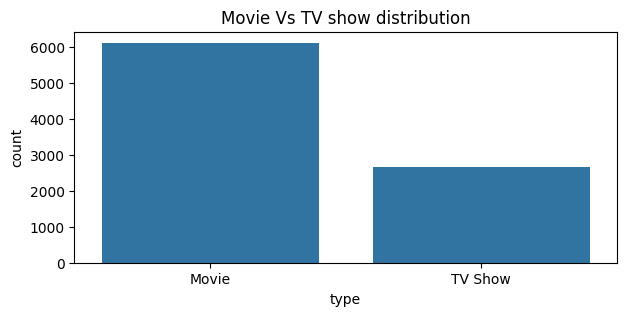

In [57]:
plt.figure(figsize = (7,3))
sns.countplot(x = 'type',data = df)
plt.title('Movie Vs TV show distribution')
plt.show()

In [58]:
# Moview are more than TV Show it is showing class imbalance

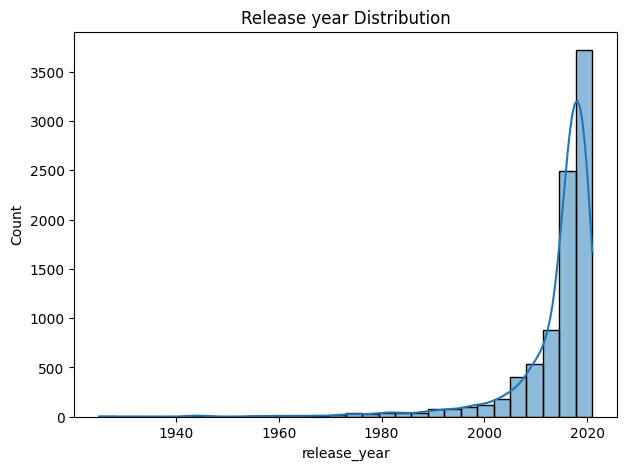

In [59]:
plt.figure(figsize = (7,5))
sns.histplot(df_model['release_year'],bins = 30,kde = True)
plt.title('Release year Distribution')
plt.show()

In [60]:
# Most content Release after 2020

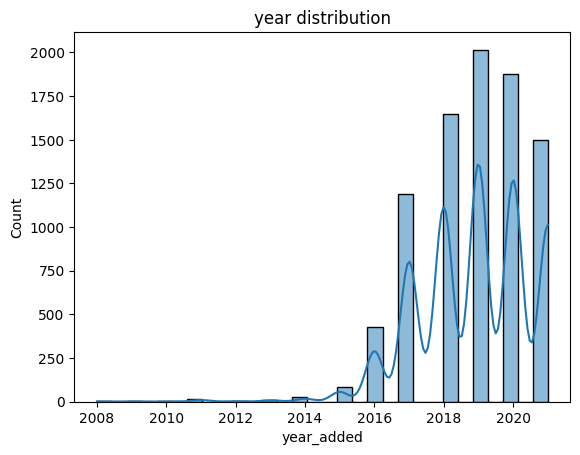

In [61]:
sns.histplot(df_model['year_added'],bins = 30,kde = True)
plt.title('year distribution')
plt.show()

In [62]:
# Netflix added more content after 2015

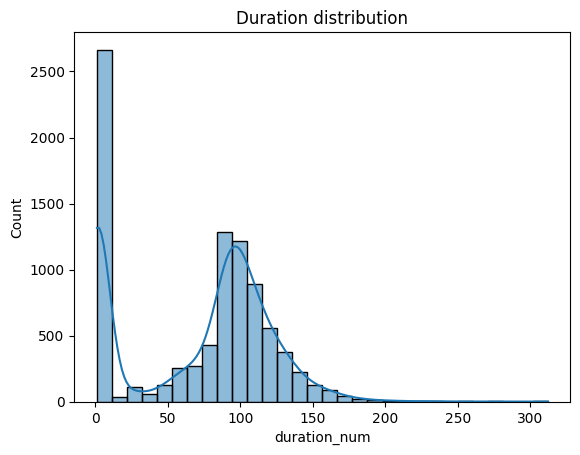

In [63]:
sns.histplot(df_model['duration_num'],bins = 30,kde = True)
plt.title('Duration distribution')
plt.show()

In [64]:
# most movie distribution between 80 and 120

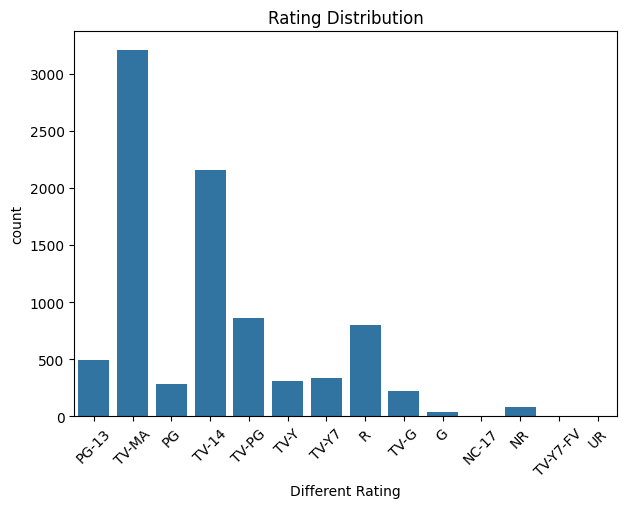

In [65]:
plt.figure(figsize = (7,5))
sns.countplot(x = 'rating',data = df_model)
plt.title('Rating Distribution')
plt.xticks(rotation = 45)
plt.xlabel('Different Rating')
plt.ylabel('count')
plt.show()

In [66]:
# MOst Common Rating TV-MA

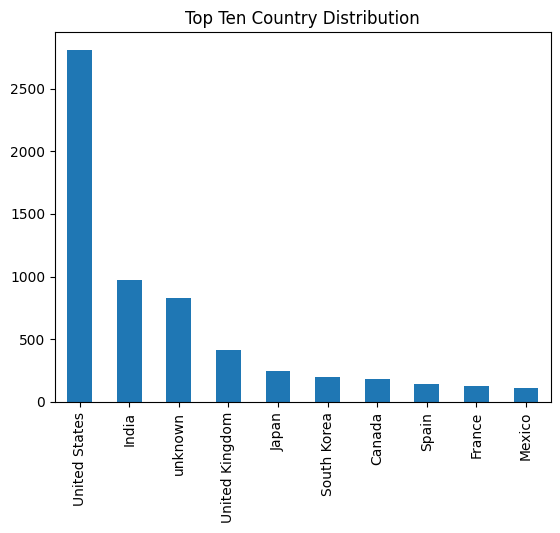

In [67]:
df_model['country'].value_counts().sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.title('Top Ten Country Distribution')
plt.show()

In [68]:
# US produce most content

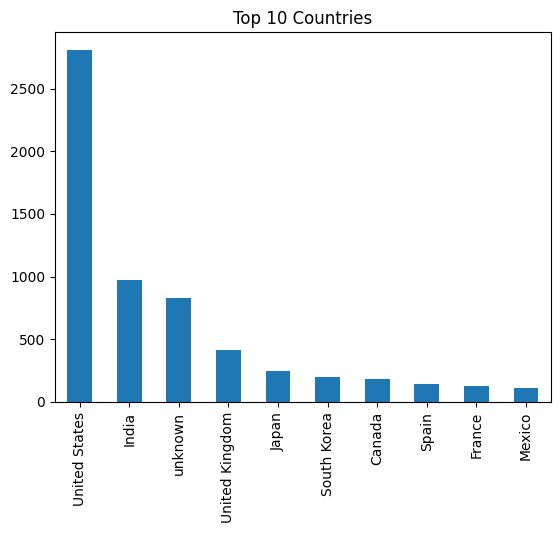

In [69]:
df_model['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

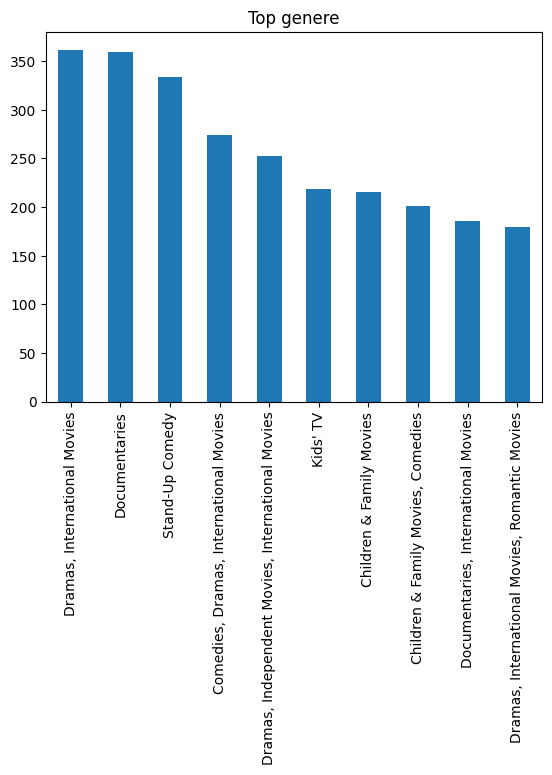

In [70]:
df_model['listed_in'].value_counts().head(10).plot(kind = 'bar')
plt.title('Top genere')
plt.show()

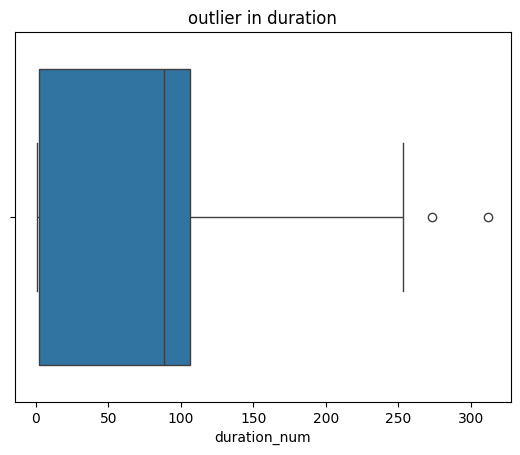

In [71]:
sns.boxplot(x = df_model['duration_num'])
plt.title('outlier in duration')
plt.show()

In [72]:
# Some movie ha very high duration

In [73]:
df_model.describe().round(2)

,release_year,year_added,month_added,duration_num
count,8794.00,8794.00,8794.00,8794.00
mean,2014.18,2018.87,6.65,69.92
std,8.82,1.57,3.44,50.80
min,1925.00,2008.00,1.00,1.00
25%,2013.00,2018.00,4.00,2.00
50%,2017.00,2019.00,7.00,88.00
75%,2019.00,2020.00,10.00,106.00
max,2021.00,2021.00,12.00,312.00


In [74]:
# BIVARIATE + MULTIVARIATE ANALYSIS
# Purpose of Bivariate Analysis:
#• Analyze the relationship between two variables
#• Understand the relationship between target and features
#• Identify important features
# Purpose of Multivariate Analysis:
#• Analyze the combined relationship among multiple features

In [75]:
# This is the most important EDA phase because it reveals which features influence the target.

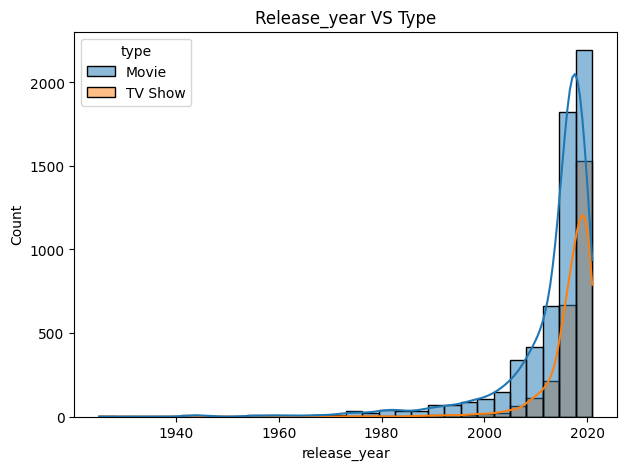

In [76]:
plt.figure(figsize = (7,5))
sns.histplot(x = 'release_year',data = df_model,hue = 'type',bins = 30,kde = True)
plt.title('Release_year VS Type')
plt.show()

In [77]:
df_model.groupby('type')['release_year'].value_counts(normalize = True).round(2)

type     release_year
Movie    2018            0.13
         2017            0.12
         2016            0.11
         2019            0.10
         2020            0.08
                         ... 
TV Show  1979            0.00
         1981            0.00
         1985            0.00
         1989            0.00
         1991            0.00
Name: release_year, Length: 119, dtype: float64

In [78]:
df_model.groupby('release_year')['type'].value_counts(normalize = True).round(2)

release_year  type   
1925          TV Show    1.00
1942          Movie      1.00
1943          Movie      1.00
1944          Movie      1.00
1945          Movie      0.75
                         ... 
2019          TV Show    0.39
2020          Movie      0.54
              TV Show    0.46
2021          TV Show    0.53
              Movie      0.47
Name: type, Length: 119, dtype: float64

In [79]:
# Movie more frequent TV Show increased after 2010

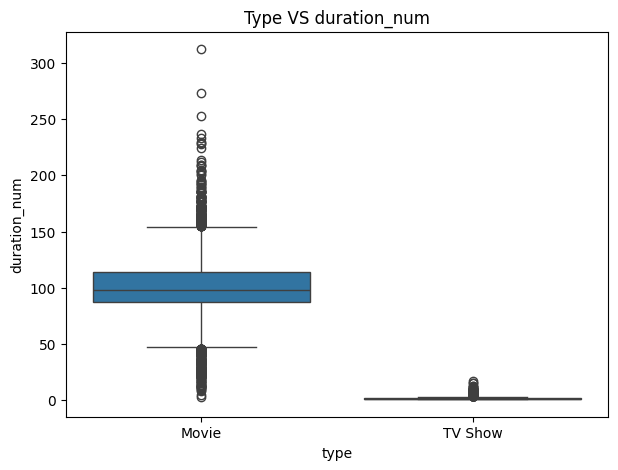

In [80]:
plt.figure(figsize = (7,5))
sns.boxplot(x = 'type',y = 'duration_num',data = df_model)
plt.title('Type VS duration_num')
plt.show()

In [81]:
# most movie is between 80 to 120 min and tv show has wider range

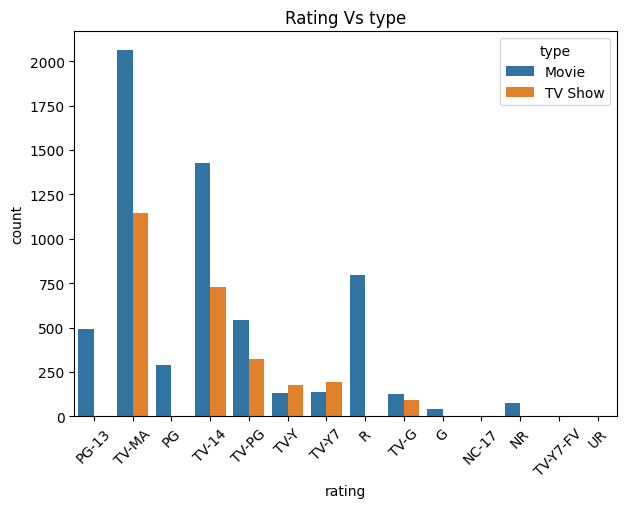

In [82]:
plt.figure(figsize = (7,5))
sns.countplot(x = 'rating',hue = 'type',data = df_model)
plt.xticks(rotation = 45)
plt.title('Rating Vs type')
plt.xlabel('rating')
plt.ylabel('count')
plt.show()

In [83]:
# TV-Ma most common for both some rating specific for TV show

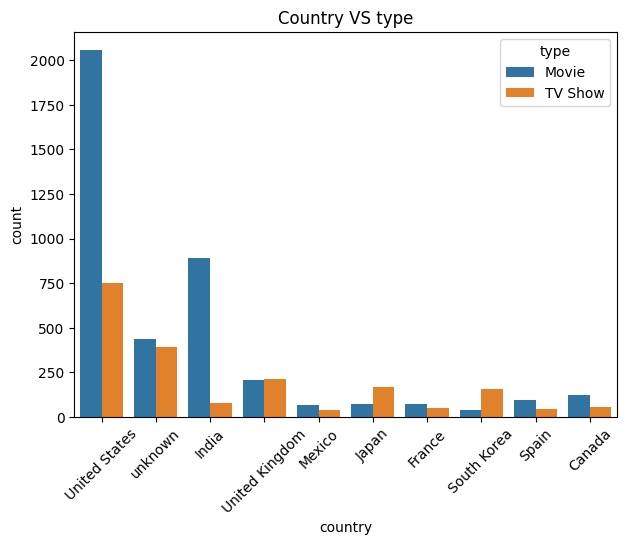

In [84]:
top_countries = df_model['country'].value_counts().head(10).index
plt.figure(figsize =(7,5))
sns.countplot(data = df_model[df_model['country'].isin(top_countries)],x = 'country',hue = 'type')
plt.title('Country VS type')
plt.xticks(rotation = 45)
plt.show()
          

In [85]:
# USA peoduce more movie and TV show

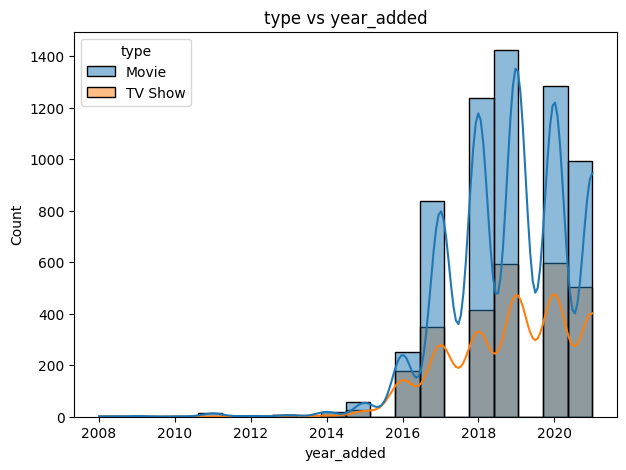

In [86]:
plt.figure(figsize = (7,5))
sns.histplot(x = 'year_added',hue = 'type',data = df_model,bins = 20,kde = True)
plt.title('type vs year_added')
plt.show()

In [87]:
# Netflix added more content after 2015

In [88]:
# MULTIVARIATE ANALYSIS
# Correlation Matrix (Numerical Features)

In [89]:
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int64
month_added              int64
duration_num             int64
dtype: object

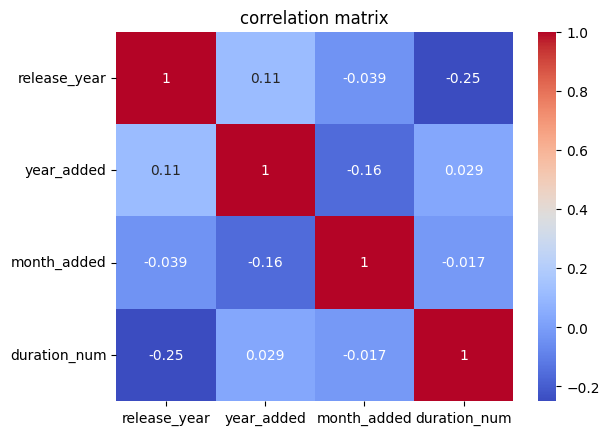

In [90]:
num_cols = ['release_year','year_added','month_added','duration_num']
corr = df_model[num_cols].corr()
sns.heatmap(corr,annot = True,cmap = 'coolwarm')
plt.title('correlation matrix')
plt.show()

In [91]:
# Helps to detect multicolinearity

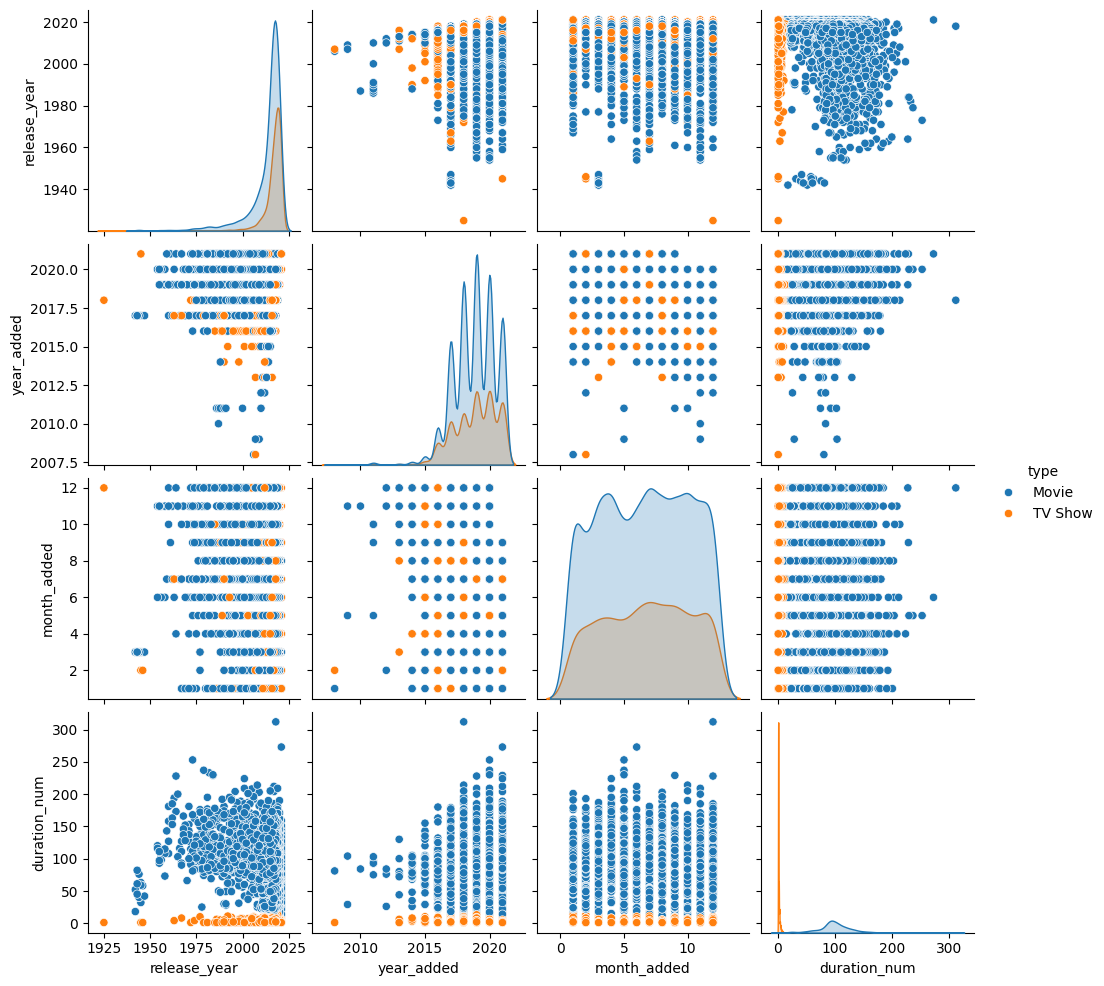

In [92]:
sns.pairplot(df_model[['release_year','year_added','month_added','duration_num','type']],hue = 'type')
plt.show()

In [93]:
top_genere = df_model['listed_in'].value_counts().head(10).index

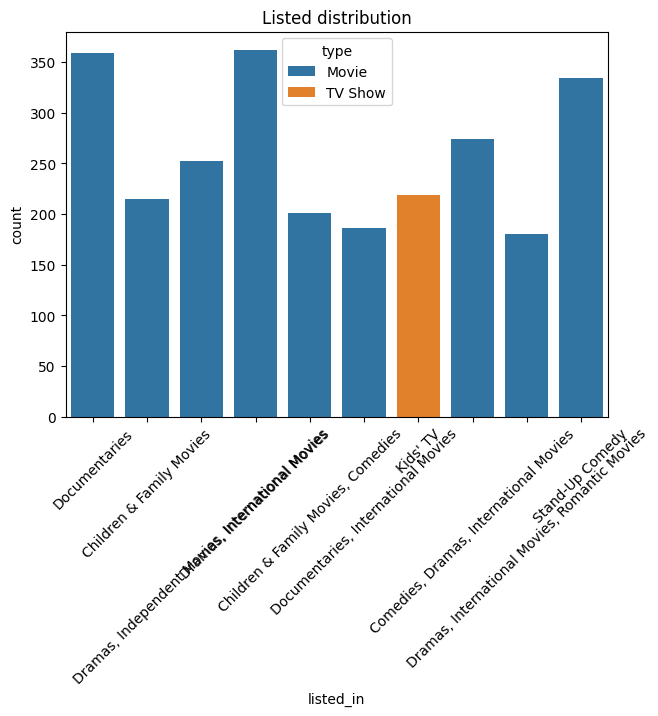

In [94]:
plt.figure(figsize = (7,5))
sns.countplot(data = df_model[df_model['listed_in'].isin(top_genere)],x = 'listed_in',hue = 'type')
plt.title('Listed distribution')
plt.xticks(rotation = 45)
plt.show()

In [95]:
# HYPOTHESIS TESTING
#Purpose of Hypothesis Testing:

#• To check whether the relationship between a feature and the target is statistically significant or not
#• To identify whether it's random chance or a real relationship
#• To validate feature importance

In [96]:
#Null Hypothesis (H₀)
#Means: No relationship exists between the variables
#Example: Movie duration and TV show duration are the same

#Alternative Hypothesis (H₁)
#Means: A relationship exists between the variables
#Example: Movie duration and TV show duration are different

In [97]:
#If p-value < 0.05 → Reject Null Hypothesis
#If p-value > 0.05 → Accept Null Hypothesis
#P-value helps determine statistical significance.

In [98]:
from scipy import stats

In [99]:
#TEST-1: T-TEST
#(Compares the mean between two groups)

#Use when:

#Analyzing Numerical vs Binary Categorical variables

#Example:

#duration_num (numerical) vs type (binary categorical - Movie/TV Show)

In [100]:
movie_duration = df_model[df_model['type'] == 'Movie']['duration_num']

In [101]:
TV_duration = df_model[df_model['type'] == 'TV Show']['duration_num']

In [102]:
t_stat,p_value = stats.ttest_ind(movie_duration,TV_duration)

In [103]:
print(t_stat)
print('PValue:',p_value)

178.42035496998682
PValue: 0.0


In [104]:
#Since p_value < 0.05 we reject null hypothesis and there is significant evidence to conclude that the relationship
#exists between duratiion_num and type

In [105]:
#TEST-2: CHI-SQUARE TEST
#(Most important test for categorical features)

#Use when:
#Analyzing Categorical vs Categorical variables
#Example:
#type (Movie/TV Show) vs rating (PG-13, R, TV-MA, etc.)

In [106]:
#H0 : Movie rating and TV Show rating is equal no significant difference
#H1 : Movie rating and TV show rating is different and exist relationship 

In [107]:
cont_table = pd.crosstab(df_model['type'],df_model['rating'])

In [108]:
chi_stat,p_value,dof,expected = stats.chi2_contingency(cont_table)

In [109]:
print(chi_stat)
print(p_value)
print(dof)
print(expected)

1044.6688903758443
4.4373048214820157e-215
13
[[2.85703889e+01 2.09051626e+00 5.50502615e+01 1.99992722e+02
  3.41450989e+02 5.56774164e+02 1.50308119e+03 1.53304526e+02
  2.23615556e+03 5.99978167e+02 2.13232659e+02 2.32047305e+02
  4.18103252e+00 2.09051626e+00]
 [1.24296111e+01 9.09483739e-01 2.39497385e+01 8.70072777e+01
  1.48549011e+02 2.42225836e+02 6.53918808e+02 6.66954742e+01
  9.72844439e+02 2.61021833e+02 9.27673414e+01 1.00952695e+02
  1.81896748e+00 9.09483739e-01]]


In [110]:
#since p_value < 0.05 we reject Null Hpothesis

In [111]:
#TEST-3: ANOVA TEST
#(Compares mean between more than 2 groups)

#Use when:
#Analyzing Numerical vs Categorical variables with more than 2 categories
#Example:
#duration_num (numerical) vs rating (categorical with multiple categories like PG-13, R, TV-MA, TV-14, etc.)

In [112]:
groups = df_model.groupby('rating')['duration_num'].apply(list)

In [113]:
f_stat,p_value = stats.f_oneway(*groups)

In [114]:
print('f_stat:',f_stat)
print('p_value:',p_value)

f_stat: 134.96042983596632
p_value: 0.0


In [115]:
#since p_value < 0.05 we reject null hypothesis

In [116]:
#TEST-4: CORRELATION TEST
#(Analyzes relationship between two numerical variables)

#Use when:
#Analyzing Numerical vs Numerical variables
#Example:
#release_year vs duration_num (checking if movie duration has changed over the years)

In [117]:
# H0: Movie duration is same over the year
# H1: movie duration is changed not same over the year

In [118]:
corr,p_value = stats.pearsonr(df_model['release_year'],df_model['duration_num'])

In [119]:
print(corr)
print(p_value)

-0.24992470797586688
2.475815145400079e-125


In [120]:
# since p_value < 0.05 we reject null hypothesis

In [121]:
#Interpretation

#Correlation Range:

#+1 = Strong positive correlation (both variables increase together)

#0 = No correlation (no relationship between variables)

#-1 = Strong negative correlation (one increases, other decreases)


In [122]:
# HERE CORR = -0.25

In [123]:
#TEST-5 : CONFIDENCE INTERVAL

In [124]:
#What is Confidence Interval?

# It tells the range where the population's true mean is likely to fall with 95% confidence
# A way to estimate population parameters from sample data

In [125]:
mean = df_model['duration_num'].mean()     # 1. Calculate sample average
std = df_model['duration_num'].std()        # 2. Measure data spread (variation)
n = len(df_model)                            # 3. Determine sample size

# 4. Lower limit
ci_low = mean - 1.96 * (std / (n**0.5))

# 5. Upper limit
ci_high = mean + 1.96 * (std / (n**0.5))

In [126]:
print(ci_low)
print(ci_high)

68.85847497113909
70.98187071910425


In [127]:
# "We are 95% confident that the true population mean of duration lies between 68.86 and 70.98"

In [128]:
#Example:

#If movies average duration = 50 minutes

#Confidence Interval = 48 to 52 minutes

#Meaning:

#We are 95% confident that the true average duration of all movies (population) lies between 48 and 52 minutes

#What is 1.96?

#This value is used for 95% confidence level
#Means there's a 95% chance that the true value falls within this range

#Benefit:

#Indicates how accurate our estimate is
#Narrower range = more precise estimate

In [129]:
#Test	                 Use case
#T-Test	            numerical vs binary categorical
#Chi-Square	        categorical vs categorical
#ANOVA	            numerical vs multi categorical
#Correlation	    numerical vs numerical
#Confidence         Interval	estimate range

In [130]:
# FEATURE ENGINEERING

In [131]:
#Purpose of Feature Engineering:

#Convert raw data into useful features
#Create new features from existing data
#Improve model accuracy and performance
#Extract hidden patterns from data

#Feature engineering is the process of creating new meaningful features from existing data to improve model performance

In [132]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,90
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,2


In [133]:
df.shape

(8794, 15)

In [134]:
# Create CONTENT AGE Feature
# This tells how old content is when added to Netflix.

In [135]:
df['content_age'] = df['year_added'] - df['release_year']

In [136]:
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int64
month_added              int64
duration_num             int64
content_age              int64
dtype: object

In [137]:
# some Feature engineering already done previously like duration_num,extract year,month from date_added and make columns

In [138]:
df['is_movie'] = df['type'].map({'Movie':1,'TV Show':0})

In [139]:
df['is_movie'].value_counts(normalize = True).round(2)

1    0.7
0    0.3
Name: is_movie, dtype: float64

In [140]:
df.shape

(8794, 17)

In [141]:
df['primary_genere'] = df['listed_in'].apply(lambda x: x.split(',')[0])

In [142]:
df['primary_genere'].head()

0             Documentaries
1    International TV Shows
2            Crime TV Shows
3                Docuseries
4    International TV Shows
Name: primary_genere, dtype: object

In [143]:
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0])

In [144]:
df.dtypes

show_id                    object
type                       object
title                      object
director                   object
cast                       object
country                    object
date_added         datetime64[ns]
release_year                int64
rating                     object
duration                   object
listed_in                  object
description                object
year_added                  int64
month_added                 int64
duration_num                int64
content_age                 int64
is_movie                    int64
primary_genere             object
primary_country            object
dtype: object

In [145]:
df_model = df.drop(columns = ['show_id','title','description','date_added','duration','listed_in','country'],axis = 1)

In [146]:
df_model.head()

,type,director,cast,release_year,rating,year_added,month_added,duration_num,content_age,is_movie,primary_genere,primary_country
0,Movie,Kirsten Johnson,unknown,2020,PG-13,2021,9,90,1,1,Documentaries,United States
1,TV Show,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021,TV-MA,2021,9,2,0,0,International TV Shows,South Africa
2,TV Show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021,TV-MA,2021,9,1,0,0,Crime TV Shows,unknown
3,TV Show,unknown,unknown,2021,TV-MA,2021,9,1,0,0,Docuseries,unknown
4,TV Show,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021,TV-MA,2021,9,2,0,0,International TV Shows,India


In [147]:
df_model.dtypes

type               object
director           object
cast               object
release_year        int64
rating             object
year_added          int64
month_added         int64
duration_num        int64
content_age         int64
is_movie            int64
primary_genere     object
primary_country    object
dtype: object

In [148]:
#Feature	             Purpose
#year_added	             Netflix growth
#month_added	         seasonal trend
#content_age	         content freshness
#duration_num	         numeric duration
#is_movie	             binary feature
#primary_genre	         simplified genre
#primary_country	     simplified country

In [149]:
# ENCODING

In [150]:
#Purpose of Encoding:
#Convert categorical features into numerical format
#Make data suitable for model training

# Encoding converts categorical features into numerical form so that machine learning models can process them

In [151]:
df_model.drop(['is_movie'],axis = 1,inplace = True)

In [152]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8794 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   type             8794 non-null   object
 1   director         8794 non-null   object
 2   cast             8794 non-null   object
 3   release_year     8794 non-null   int64 
 4   rating           8794 non-null   object
 5   year_added       8794 non-null   int64 
 6   month_added      8794 non-null   int64 
 7   duration_num     8794 non-null   int64 
 8   content_age      8794 non-null   int64 
 9   primary_genere   8794 non-null   object
 10  primary_country  8794 non-null   object
dtypes: int64(5), object(6)
memory usage: 824.4+ KB


In [153]:
df_model['type'] = df_model['type'].map({
    'Movie':1,
    'TV Show':0
})


In [154]:
cat_cols = df_model.select_dtypes(include = 'object').columns

In [155]:
cat_cols

Index(['director', 'cast', 'rating', 'primary_genere', 'primary_country'], dtype='object')

In [156]:
df_model = pd.get_dummies(df_model,columns = ['rating', 'primary_genere', 'primary_country'],drop_first = True)

In [157]:
df_model.shape

(8794, 142)

In [158]:
from sklearn.preprocessing import LabelEncoder

In [159]:
le = LabelEncoder()

In [160]:
df_model['director'] = le.fit_transform(df_model['director'])

In [161]:
df_model['cast'] = le.fit_transform(df_model['cast'])

In [162]:
df_model.head(2)

,type,director,cast,release_year,year_added,month_added,duration_num,content_age,rating_NC-17,rating_NR,...,primary_country_Ukraine,primary_country_United Arab Emirates,primary_country_United Kingdom,primary_country_United States,primary_country_Uruguay,primary_country_Venezuela,primary_country_Vietnam,primary_country_West Germany,primary_country_Zimbabwe,primary_country_unknown
0,1,2295,7666,2020,2021,9,90,1,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,4515,409,2021,2021,9,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [163]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8794 entries, 0 to 8806
Columns: 142 entries, type to primary_country_unknown
dtypes: int32(2), int64(6), uint8(134)
memory usage: 1.7 MB


In [164]:
df_model.isnull().sum().sum()

0

In [165]:
# I used mapping for target variable, one-hot encoding for categorical features, and label encoding for high-cardinality features

In [166]:
# MODELING
#The purpose of modeling:
#To train a Machine Learning model
#To learn the relationship between features and the target
#To make predictions
#I trained machine learning models to predict whether content is Movie or TV Show.

In [167]:
X = df_model.drop(['type'],axis = 1)
y = df_model['type']

In [168]:
X = X.drop(['duration_num'],axis = 1)

In [169]:
from sklearn.model_selection import train_test_split

In [170]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 7)

In [171]:
from sklearn.linear_model import LogisticRegression

In [172]:
lr = LogisticRegression(max_iter = 1000)

In [173]:
lr.fit(x_train,y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [174]:
pred1 = lr.predict(x_test)

In [175]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,pred1)
print(accuracy)

0.9971574758385446


In [176]:
from sklearn.metrics import confusion_matrix,classification_report

In [177]:
cm = confusion_matrix(y_test,pred1)

In [178]:
print(cm)

[[ 511    2]
 [   3 1243]]


In [179]:
print(classification_report(y_test,pred1))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       513
           1       1.00      1.00      1.00      1246

    accuracy                           1.00      1759
   macro avg       1.00      1.00      1.00      1759
weighted avg       1.00      1.00      1.00      1759



In [180]:
# RandomForest
from sklearn.ensemble import RandomForestClassifier

In [181]:
rf = RandomForestClassifier()

In [182]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [183]:
y_pred_rf = rf.predict(x_test)

In [184]:
print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

0.9954519613416714
[[ 509    4]
 [   4 1242]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       513
           1       1.00      1.00      1.00      1246

    accuracy                           1.00      1759
   macro avg       0.99      0.99      0.99      1759
weighted avg       1.00      1.00      1.00      1759



In [185]:
# HYPERPARAMETER TUNING
#The purpose of hyperparameter tuning is:
#• To improve model performance
#• To find the best parameter combination
#• To reduce overfitting
# Hyperparameter tuning is the process of optimizing model parameters to improve performance.
# What is Hyperparameter?
# Example Random Forest parameters:
# n_estimators      → number of trees
# max_depth         → tree depth
# min_samples_split → minimum samples to split
# min_samples_leaf  → minimum samples per leaf

In [186]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [187]:
rf = RandomForestClassifier(random_state = 7)

In [188]:
# Define Hyperparameter Grid
# This defines combinations to test.
param_grid = {'n_estimators': [50,100,200],
              'max_depth': ['None',10,20],
              'min_samples_split':[2,5],
              'min_samples_leaf':[1,2]}
# Total Combination = 3*3*2*2 = 36 combinations

In [189]:
# Apply GridSearchCV
grid_search = GridSearchCV(estimator = rf,
                           param_grid = param_grid,
                           cv = 5,
                           scoring = 'accuracy',
                           n_jobs = -1)
#cv=5 → 5-fold cross validation
#n_jobs=-1 → use all CPU cores

In [190]:
# This find best paramerts
grid_search.fit(x_train,y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
60 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py", line 492, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Admin\anaconda3\Lib\site-packages

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': ['None', 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [191]:
print('Best Paramerts:',grid_search.best_params_)

Best Paramerts: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


In [192]:
best_model = grid_search.best_estimator_

In [193]:
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [194]:
y_pred = best_model.predict(x_test)

In [195]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9960204661739624


In [196]:
# GridSearchCV vs RandomizedSearchCV
#GridSearchCV	                   RandomizedSearchCV
#Tests ALL combinations	           Tests RANDOM combinations
#Slow	                           Fast
#Best for small data	           Best for large data
#Exhaustive search	               Smart sampling

In [197]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [198]:
# Define Parameter Distribution
# GridSearch → fixed values
# RandomSearch → range of values
param_dist = {'n_estimators': [50,100,200,300,500],
             'max_depth': [None,10,20,30,40],
             'min_samples_split': [2,5,10],
             'min_samples_leaf': [1,2,4],
              'max_features':['sqrt','log2']}

In [199]:
# Create RandomizedSearchCV Object
random_search = RandomizedSearchCV(estimator = RandomForestClassifier(random_state = 7),
                                   param_distributions = param_dist,
                                   n_iter=20,        # number of combinations to try
                                   cv = 5,
                                   scoring = 'accuracy',
                                   n_jobs = -1,
                                   random_state = 7)
# n_iter=20 → tries 20 random combinations
# cv=5 → 5-fold cross validation
# n_jobs=-1 → use full CPU
                                   

In [200]:
random_search.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=7)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [201]:
print('Best Parameters:',random_search.best_params_)

Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [202]:
best_random_model = random_search.best_estimator_

In [203]:
best_random_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [204]:
y_pred_random = best_random_model.predict(x_test)

In [205]:
accuracy = accuracy_score(y_test,y_pred_random)
print(accuracy)

0.9965889710062535


In [206]:
# I use GridSearchCV when parameter space is small and RandomizedSearchCV when parameter space is large and training time is limited.

In [207]:
# FEATURE SELECTION
#The purpose of feature selection is:
#• To select the most important features
#• To improve model performance
#• To reduce overfitting
#• To increase training speed

In [208]:
X = df_model.drop('type', axis=1)
y = df_model['type']

In [209]:
#PART-1 : SelectKBest
#Concept
#SelectKBest selects top K best features based on statistical test.
#For classification → use chi2 test.

In [210]:
from sklearn.feature_selection import SelectKBest,f_classif
selector = SelectKBest(score_func = f_classif,k = 10)
X_new = selector.fit_transform(X,y)
# I used f_classif because chi-square requires non-negative values, and my dataset contained negative values in content_age feature.

In [211]:
X.min().min()

-3

In [212]:
selected_feature = X.columns[selector.get_support()]

In [213]:
print('best_feature from selectkbest:',selected_feature)

best_feature from selectkbest: Index(['director', 'duration_num', 'primary_genere_Anime Series',
       'primary_genere_British TV Shows', 'primary_genere_Comedies',
       'primary_genere_Crime TV Shows', 'primary_genere_Docuseries',
       'primary_genere_Dramas', 'primary_genere_International TV Shows',
       'primary_genere_Kids' TV'],
      dtype='object')


In [214]:
X_selected = X[selected_feature]

In [215]:
x_train,x_test,y_train,y_test = train_test_split(X_selected,y,test_size = 0.2,random_state = 7)

In [216]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [217]:
y_pred_select = rf.predict(x_test)

In [218]:
print('accuracy:',accuracy_score(y_test,y_pred_select))

accuracy: 0.9982944855031268


In [219]:
#PART-2 : PCA (Principal Component Analysis)
#Concept
#PCA reduces dimensionality by creating new features.
#Example:
#10 features → 5 principal components

In [220]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 5)
X_pca = pca.fit_transform(X)

In [221]:
x_train,x_test,y_train,y_test = train_test_split(X_pca,y,test_size = 0.2,random_state = 7)

In [222]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [223]:
y_pred_pca = rf.predict(x_test)

In [224]:
print('accuracy:',accuracy_score(y_test,y_pred_pca))

accuracy: 0.9977259806708357


In [225]:
#PART-3 : RFE (Recursive Feature Elimination)
#Concept
#RFE removes least important features step by step.
#Why Logistic Regression is preferred for RFE:
#• Faster: Random Forest is slower in comparison
#• More stable feature ranking
#• Industry standard practice: Most tutorials and interviews use Logistic Regression for RFE

#Can RFE work with Random Forest?
#Answer:
# Yes, RFE works with any model that provides feature importance or coefficients, including Random Forest and Logistic Regression.

In [226]:
from sklearn.feature_selection import RFE
lr = LogisticRegression(max_iter = 1000)
rfe = RFE(lr,n_features_to_select = 10)
rfe.fit_transform(X,y)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [227]:
selected_features = X.columns[rfe.get_support()]
X_rfe = X[selected_features]
x_train,x_test,y_train,y_test = train_test_split(X_rfe,y,test_size = 0.2,random_state = 7)

In [228]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [229]:
y_pred_rfe = rf.predict(x_test)

In [230]:
print('accuracy:',accuracy_score(y_test,y_pred_rfe))

accuracy: 0.9113132461625923


In [231]:
#PART-4: LDA (Linear Discriminant Analysis)
#Concept
#LDA serves dual purposes:
#• Feature extraction technique: Reduces dimensionality while preserving class discriminatory information
#• Classification method: Can directly classify data points into categories
#Common Applications:
#• Face recognition
#• Customer classification
#• Medical diagnosis
#• Pattern recognition tasks

In [232]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components = 1)
X_lda = lda.fit_transform(X,y)

In [233]:
x_train,x_test,y_train,y_test = train_test_split(X_lda,y,test_size = 0.2,random_state = 7)

In [234]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [235]:
y_pred_lda = rf.predict(x_test)

In [236]:
print('accuracy',accuracy_score(y_test,y_pred_lda))

accuracy 0.9994314951677089


In [237]:
#FINAL COMPARISON TABLE
#Method	                      Purpose
#SelectKBest	              statistical selection
#PCA	                      dimensionality reduction
#RFE	                      recursive selection
#LDA	                      maximize class separation

In [238]:
#Train Final Model

In [239]:
final_model = RandomForestClassifier(n_estimators = 200,max_depth = None,random_state = 7)

In [240]:
final_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [241]:
y_pred_final = final_model.predict(x_test)

In [242]:
final_accuracy = accuracy_score(y_test,y_pred_final)
print(final_accuracy)

0.9994314951677089


In [243]:
cm_final = confusion_matrix(y_test,y_pred_final)

In [244]:
print(cm_final)

[[ 513    0]
 [   1 1245]]


In [245]:
final_repots = classification_report(y_test,y_pred_final)

In [246]:
print(final_repots)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       513
           1       1.00      1.00      1.00      1246

    accuracy                           1.00      1759
   macro avg       1.00      1.00      1.00      1759
weighted avg       1.00      1.00      1.00      1759



In [247]:
from sklearn.metrics import roc_curve,auc

In [248]:
y_prob = final_model.predict_proba(x_test)[:,1]

In [249]:
fpr,tpr,threshold = roc_curve(y_test,y_prob)

In [250]:
roc_auc = auc(fpr,tpr)

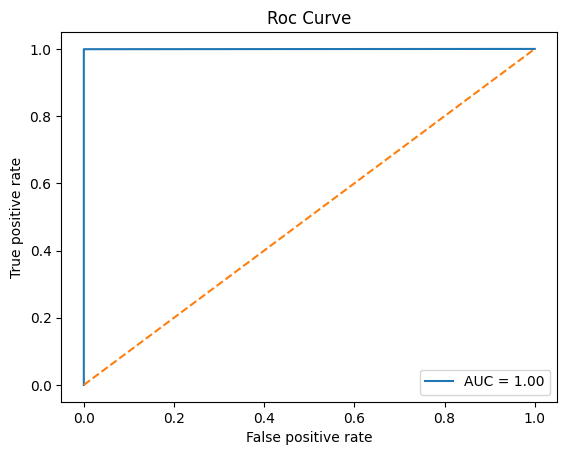

In [251]:
plt.plot(fpr,tpr,label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Roc Curve')
plt.legend()
plt.show()

In [252]:
# The REAL MODEL FOR DEPLOYMENT

In [253]:
x = df_model.drop(['type'],axis = 1)
y = df_model['type']

In [254]:
x.head()

,director,cast,release_year,year_added,month_added,duration_num,content_age,rating_NC-17,rating_NR,rating_PG,...,primary_country_Ukraine,primary_country_United Arab Emirates,primary_country_United Kingdom,primary_country_United States,primary_country_Uruguay,primary_country_Venezuela,primary_country_Vietnam,primary_country_West Germany,primary_country_Zimbabwe,primary_country_unknown
0,2295,7666,2020,2021,9,90,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,4515,409,2021,2021,9,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2105,6286,2021,2021,9,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4515,7666,2021,2021,9,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,4515,4805,2021,2021,9,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [255]:
y.shape

(8794,)

In [256]:
x.shape

(8794, 141)

In [257]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 7)

In [258]:
final_model = RandomForestClassifier(n_estimators = 200,max_depth = None,random_state = 7)

In [259]:
final_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [260]:
pred = final_model.predict(x_test)

In [261]:
final_accuracy = accuracy_score(y_test,pred)

In [262]:
final_accuracy

0.9982944855031268

In [263]:
import joblib

In [264]:
joblib.dump(final_model,'netflix_final_model.pkl')

['netflix_final_model.pkl']

In [265]:
model = joblib.load('netflix_final_model.pkl')

In [266]:
print('features:',model.n_features_in_)

features: 141


In [267]:
joblib.dump(X.columns.tolist(), "netflix_features.pkl")

['netflix_features.pkl']